In [81]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df=pd.read_csv("results/single_var/data.csv")
print(df.columns)
print("shape",df.shape)

Index(['p', 'D', 'seed', 'DX', 'D_diff', 'time', 'abs_theta'], dtype='object')
shape (76000, 7)


In [82]:
p_list=df['p'].unique()

In [83]:
df=df[df["p"]==p_list[1]]
print("shape",df.shape)

shape (38000, 7)


In [84]:
dx_list=df["DX"].unique()
print(dx_list)

[0.03571429 0.05357143 0.07142857 0.08928571 0.10714286]


In [85]:
df=df[df["DX"]==dx_list[4]]

In [86]:
df.head()

,p,D,seed,DX,D_diff,time,abs_theta
41040,5.0,0.0,10,0.107143,0.0,0.00,0.203938
41041,5.0,0.0,10,0.107143,0.0,0.01,0.101456
41042,5.0,0.0,10,0.107143,0.0,0.02,0.091171
41043,5.0,0.0,10,0.107143,0.0,0.03,0.149296
41044,5.0,0.0,10,0.107143,0.0,0.04,0.285511


In [ ]:

df=df[df["time"]==0.75]
print("shape",df.shape)

shape (100, 7)


In [88]:
df.head()

,p,D,seed,DX,D_diff,time,abs_theta
41115,5.0,0.0,10,0.107143,0.0,0.75,0.030940
41191,5.0,0.0,10,0.107143,5.0,0.75,0.079400
41267,5.0,0.0,10,0.107143,10.0,0.75,0.096733
41343,5.0,0.0,10,0.107143,15.0,0.75,0.041928
41419,5.0,0.0,10,0.107143,20.0,0.75,0.161205


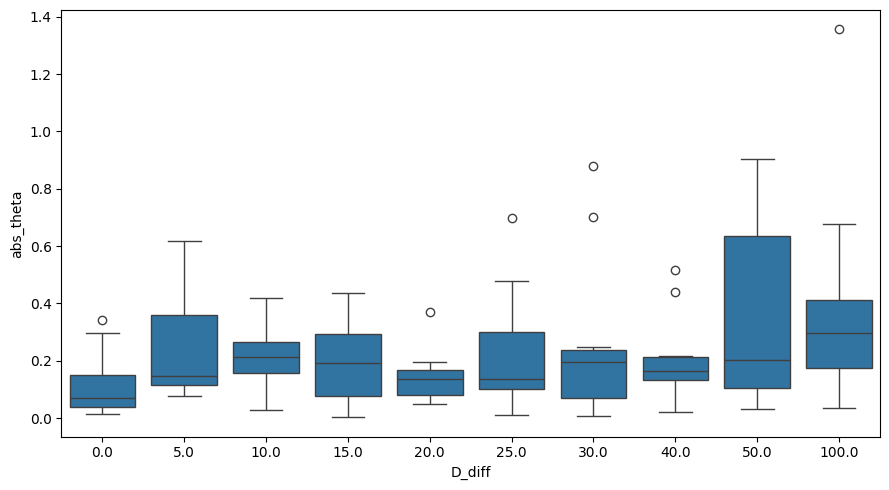

In [89]:
plt.figure(figsize=(9, 5))

df["D_diff"] = df["D_diff"].astype("category")
sns.boxplot(data=df, x="D_diff", y="abs_theta")
plt.tight_layout()

In [90]:
df["D_diff"] = df["D_diff"].astype("category")

summary = (
    df.groupby("D_diff")["abs_theta"]
    .agg(mean="mean", std="std")
    .sort_values("mean")
    .reset_index()
)

print(summary.to_string(index=False))

D_diff     mean      std
   0.0 0.116565 0.116819
  20.0 0.144319 0.094783
  15.0 0.196823 0.142976
  40.0 0.207276 0.155420
  10.0 0.223156 0.125040
  25.0 0.228825 0.214791
   5.0 0.235928 0.187116
  30.0 0.261634 0.292323
  50.0 0.345020 0.328590
 100.0 0.399739 0.382175


/var/folders/xr/y8fz998s0g5czf906q64rvx40000gn/T/ipykernel_9388/3395064099.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("D_diff")["abs_theta"]


/var/folders/xr/y8fz998s0g5czf906q64rvx40000gn/T/ipykernel_9388/3906487432.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("D_diff")["abs_theta"]


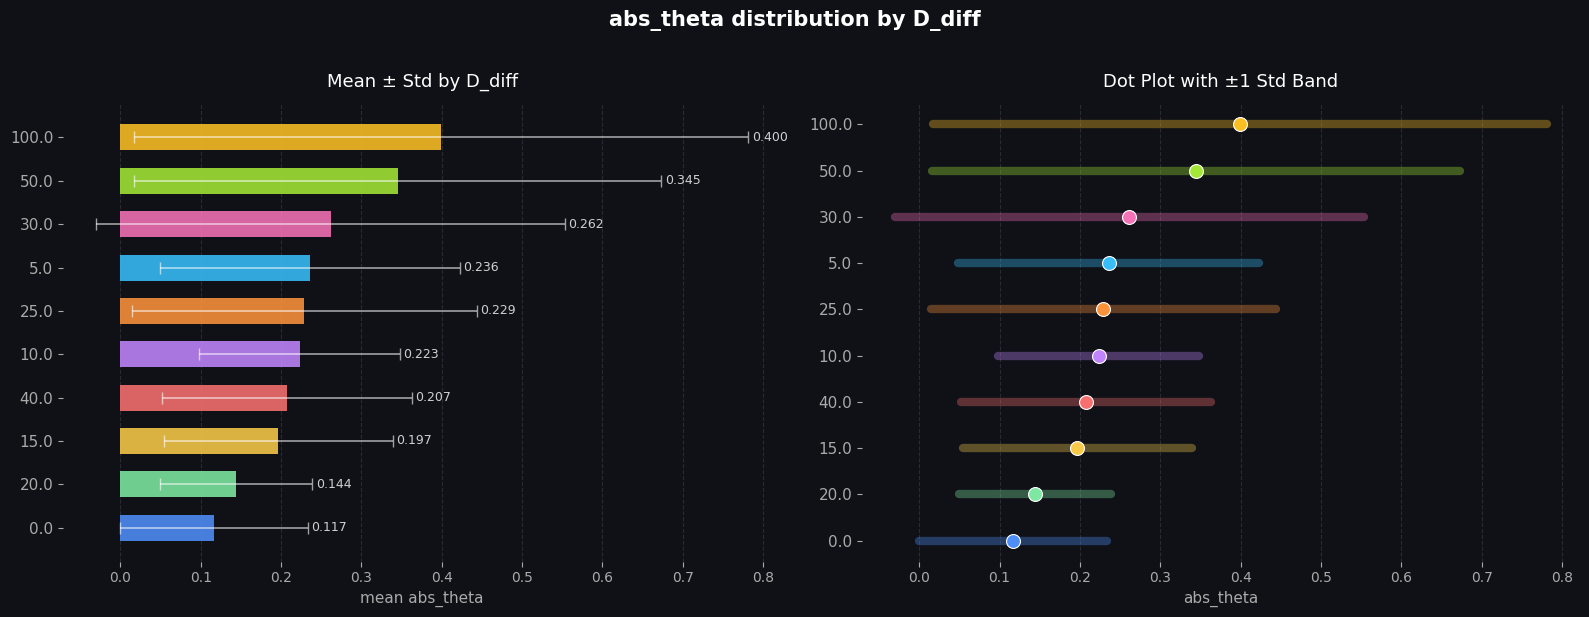

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df["D_diff"] = df["D_diff"].astype("category")

summary = (
    df.groupby("D_diff")["abs_theta"]
    .agg(mean="mean", std="std")
    .sort_values("mean")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")
for ax in axes:
    ax.set_facecolor("#0f1117")

PALETTE = ["#4f8ef7", "#7ee8a2", "#f7c948", "#f76f6f", "#c084fc",
           "#fb923c", "#38bdf8", "#f472b6", "#a3e635", "#fbbf24"]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(summary))]

# ── Plot 1: horizontal bar with error bars ──────────────────────────────────
ax1 = axes[0]
y_pos = np.arange(len(summary))
bars = ax1.barh(
    y_pos, summary["mean"],
    xerr=summary["std"],
    color=colors,
    error_kw=dict(ecolor="white", elinewidth=1.2, capsize=4, alpha=0.6),
    height=0.6,
    alpha=0.88,
)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(summary["D_diff"], color="white", fontsize=11)
ax1.set_xlabel("mean abs_theta", color="#aaaaaa", fontsize=11)
ax1.set_title("Mean ± Std by D_diff", color="white", fontsize=13, pad=12)
ax1.tick_params(colors="#aaaaaa")
ax1.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax1.xaxis.grid(True, color="#2a2a35", linewidth=0.8, linestyle="--")
ax1.set_axisbelow(True)

for bar, mean_val, std_val in zip(bars, summary["mean"], summary["std"]):
    ax1.text(
        bar.get_width() + std_val + (summary["mean"].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{mean_val:.3f}",
        va="center", ha="left", color="white", fontsize=9, alpha=0.8,
    )

# ── Plot 2: dot plot with std shading ────────────────────────────────────────
ax2 = axes[1]
for i, (_, row) in enumerate(summary.iterrows()):
    ax2.plot([row["mean"] - row["std"], row["mean"] + row["std"]],
             [i, i], color=colors[i], alpha=0.35, linewidth=6, solid_capstyle="round")
    ax2.scatter(row["mean"], i, color=colors[i], s=100, zorder=5, edgecolors="white", linewidths=0.8)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(summary["D_diff"], color="white", fontsize=11)
ax2.set_xlabel("abs_theta", color="#aaaaaa", fontsize=11)
ax2.set_title("Dot Plot with ±1 Std Band", color="white", fontsize=13, pad=12)
ax2.tick_params(colors="#aaaaaa")
ax2.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax2.xaxis.grid(True, color="#2a2a35", linewidth=0.8, linestyle="--")
ax2.set_axisbelow(True)

plt.suptitle("abs_theta distribution by D_diff", color="white", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("abs_theta_by_D_diff.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()